# Projeto — A Estrada da Visionária
**Autora —** Gisela Ceresér Kassick | **Colaboradora —** Lívia Maria Aragão

**Disciplina —** Redes Neurais | **Professor —** Prof. Dr. Daniel Cassar

---

Este notebook implementa um modelo de classificação baseado em Rede Neural Pulsada (SNN) para identificação de diferentes texturas a partir de sinais elétricos experimentais obtidos em um dispositivo de grafite em papel.

Os dados de entrada consistem em séries temporais de variação relativa de corrente e massa medida na balança, utilizada como medida da força (ou carga) aplicada sobre o dispositivo. Esses sinais são organizados em janelas deslizantes, e as amostras são classificadas em três classes correspondentes aos tipos de superfície: papel filme, papel texturizado e lixa.

## Importações

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import snntorch as snn
from snntorch import functional as SF
import random
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from pathlib import Path

## Reprodutibilidade

A semente aleatória é fixada em todas as bibliotecas relevantes para garantir que os resultados sejam reprodutíveis entre execuções. O modo determinístico do cuDNN é ativado pelo mesmo motivo.

In [2]:
SEMENTE_ALEATORIA = 42
random.seed(SEMENTE_ALEATORIA)
np.random.seed(SEMENTE_ALEATORIA)
torch.manual_seed(SEMENTE_ALEATORIA)
torch.cuda.manual_seed_all(SEMENTE_ALEATORIA)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

## Hiperparâmetros e configurações

Parâmetros centrais do experimento definidos em um único bloco para facilitar ajustes:

In [3]:
PASTA_DADOS       = "dados"
TAMANHO_TESTE     = 0.10
TAMANHO_VALIDACAO = 0.10
EPOCAS            = 300
LR                = 1e-3
JANELA            = 20        
PASSO             = 1
ATRIBUTOS         = ['variacao_relativa', 'massa_g']
TARGET            = 'rotulo'
N_CLASSES         = 3

## Carregamento dos dados

Os arquivos `Completo_Amostra{N}.csv` gerados no pré-processamento são lidos da pasta `dados/` e concatenados em um único DataFrame. Cada arquivo corresponde a uma amostra experimental e contém as colunas `variacao_relativa`, `massa_g` e `rotulo`.

In [4]:
dfs = {}
for arquivo in sorted(Path(PASTA_DADOS).glob("Completo_Amostra*.csv")):
    nome = arquivo.stem.split("_")[1]
    dfs[nome] = pd.read_csv(arquivo)

df_disps = pd.concat(dfs.values(), ignore_index=True)
df_disps.to_csv("dados_dispositivos.csv", index=False, encoding="utf-8-sig")
print(f"Shape total: {df_disps.shape}")


Shape total: (1560, 9)


## Construção das janelas temporais

Como os dados são séries temporais, a entrada dos modelos não é um instante isolado, mas uma janela de `T` instantes consecutivos. A função `criar_janelas` percorre cada amostra com um deslizamento de `PASSO` pontos e extrai segmentos de comprimento `JANELA`, atribuindo a cada janela o rótulo do último instante incluído.

Isso transforma o problema de classificação de pontos individuais em classificação de sequências, o que é especialmente adequado para a SNN, que processa os dados passo a passo no tempo.

In [5]:
def criar_janelas(df, atributos, target, janela, passo):
    X, y = [], []
    valores = df[atributos].values
    rotulos = df[target].values
    for i in range(0, len(df) - janela, passo):
        X.append(valores[i : i + janela])
        y.append(rotulos[i + janela - 1])
    return np.array(X), np.array(y)

X, y = criar_janelas(df_disps, ATRIBUTOS, TARGET, JANELA, PASSO)
print(f"Janelas: X={X.shape}  y={y.shape}")


Janelas: X=(1540, 20, 2)  y=(1540,)


## Divisão e normalização

Os índices são divididos em treino (~81%), validação (~9%) e teste (10%), garantindo que as proporções sejam mantidas.

A normalização é feita com `StandardScaler`, cujos parâmetros (média e desvio padrão) são estimados somente a partir do conjunto de treino e aplicados aos demais conjuntos. Isso evita vazamento de informação do teste para a normalização.

Como cada janela tem forma `(T, F)`, os dados são temporariamente achatados para `(-1, F)` antes da normalização e depois restaurados à forma original.

In [6]:
# Divisão
indices = np.arange(len(X))
idx_tv, idx_teste = train_test_split(indices, test_size=TAMANHO_TESTE,
                                     random_state=SEMENTE_ALEATORIA)
idx_treino, idx_val = train_test_split(idx_tv,
                                       test_size=TAMANHO_VALIDACAO / (1 - TAMANHO_TESTE),
                                       random_state=SEMENTE_ALEATORIA)

X_treino, y_treino = X[idx_treino], y[idx_treino]
X_val,    y_val    = X[idx_val],    y[idx_val]
X_teste,  y_teste  = X[idx_teste],  y[idx_teste]

# Normalização
n_feat = len(ATRIBUTOS)
scaler = StandardScaler()
scaler.fit(X_treino.reshape(-1, n_feat))

X_treino = scaler.transform(X_treino.reshape(-1, n_feat)).reshape(X_treino.shape)
X_val    = scaler.transform(X_val.reshape(-1, n_feat)).reshape(X_val.shape)
X_teste  = scaler.transform(X_teste.reshape(-1, n_feat)).reshape(X_teste.shape)

## Conversão para tensores

Os arrays NumPy são convertidos para tensores PyTorch: `float32` para as entradas e `long` para os rótulos (necessário para `CrossEntropyLoss` e `ce_count_loss`).

A operação `permute(1, 0, 2)` reorganiza as dimensões de `(N, T, F)` para `(T, N, F)`, onde:
- `T` — passos temporais da janela (dimensão sequencial)
- `N` — número de amostras no batch
- `F` — número de atributos (features)

Esse formato é exigido pela SNN, que itera sobre a dimensão `T` no loop do `forward`.

In [7]:
def para_tensor(X, y):
    Xt = torch.tensor(X, dtype=torch.float32).permute(1, 0, 2)  # (T, N, F)
    yt = torch.tensor(y, dtype=torch.long)
    return Xt, yt

X_tr, y_tr = para_tensor(X_treino, y_treino)
X_vl, y_vl = para_tensor(X_val,    y_val)
X_ts, y_ts = para_tensor(X_teste,  y_teste)


## Arquitetura da SNN

A rede é composta por três blocos Linear → LIF em sequência:

```
Entrada (2) → Linear(2→32) → LIF → Linear(32→16) → LIF → Linear(16→3) → LIF
```

O neurônio Leaky Integrate-and-Fire (LIF) modela a dinâmica de um neurônio biológico simplificado: o potencial de membrana acumula a corrente de entrada e decai exponencialmente com fator `β = 0,9` a cada passo. Quando o potencial ultrapassa o limiar, o neurônio dispara um pulso (*spike*) binário e o potencial é reiniciado.

No `forward`, o loop sobre os `T` passos temporais processa cada instante da janela sequencialmente, atualizando os estados de membrana `mem1`, `mem2`, `mem3`. Os pulsos gerados na camada de saída são empilhados ao longo do tempo em `spk3_rec`.

A classificação final é feita pela classe com o maior número de pulsos acumulados ao longo da janela.

In [8]:
class DispositivosSNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1  = nn.Linear(2, 32)
        self.lif1 = snn.Leaky(beta=0.9)

        self.fc2  = nn.Linear(32, 16)
        self.lif2 = snn.Leaky(beta=0.9)

        self.fc3  = nn.Linear(16, 3)
        self.lif3 = snn.Leaky(beta=0.9)

    def forward(self, x):
        
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        spk3_rec = []

        for t in range(x.shape[0]):
            spk1, mem1 = self.lif1(self.fc1(x[t]), mem1)
            spk2, mem2 = self.lif2(self.fc2(spk1), mem2)
            spk3, mem3 = self.lif3(self.fc3(spk2), mem3)
            spk3_rec.append(spk3)

        return torch.stack(spk3_rec) 


## Treinamento e avaliação

O modelo é otimizado com Adam (`lr = 1e-3`) e a função de perda `ce_count_loss` da biblioteca snnTorch, que aplica entropia cruzada sobre a contagem de pulsos de saída — equivalente conceitualmente à `CrossEntropyLoss` da MLP, mas adaptada para a representação em pulsos.

A cada época:
1. O modelo é colocado em modo treino, o gradiente é zerado e o forward é executado
2. A perda é retropropagada e os pesos são atualizados
3. Em modo de avaliação, são calculadas a perda e a acurácia no treino e na validação

A predição final no teste soma os pulsos ao longo do tempo (`sum(0)`) e atribui a classe com maior contagem (`argmax(1)`).

In [9]:
model     = DispositivosSNN()
fn_perda  = SF.ce_count_loss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
train_losses, val_losses = [], []

for epoca in range(EPOCAS):
    model.train()
    optimizer.zero_grad()
    loss = fn_perda(model(X_tr), y_tr)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        out_vl = model(X_vl) 
        out_tr = model(X_tr)

        val_loss = fn_perda(out_vl, y_vl).item()
        val_losses.append(val_loss)

        acc_tr = (out_tr.sum(0).argmax(1) == y_tr).float().mean().item() * 100
        acc_vl = (out_vl.sum(0).argmax(1) == y_vl).float().mean().item() * 100

        if epoca % 50 == 0 or epoca == EPOCAS - 1:
            print(f"Época {epoca:4d} | loss treino: {loss.item():.4f} "
                  f"| loss val: {val_loss:.4f} "
                  f"| acc treino: {acc_tr:.2f}% | acc val: {acc_vl:.2f}%")

model.eval()
with torch.no_grad():
    preds = model(X_ts).sum(0).argmax(dim=1)  

acc = (preds == y_ts).float().mean().item() * 100
print(f"\nAcurácia - Teste: {acc:.2f}%")

Época    0 | loss treino: 1.8062 | loss val: 1.6040 | acc treino: 33.44% | acc val: 39.61%
Época   50 | loss treino: 1.0524 | loss val: 1.0356 | acc treino: 38.64% | acc val: 44.81%
Época  100 | loss treino: 1.0317 | loss val: 1.0038 | acc treino: 40.26% | acc val: 46.75%
Época  150 | loss treino: 1.0219 | loss val: 0.9485 | acc treino: 39.94% | acc val: 52.60%
Época  200 | loss treino: 0.9894 | loss val: 0.9286 | acc treino: 45.29% | acc val: 54.55%
Época  250 | loss treino: 0.9823 | loss val: 0.9618 | acc treino: 44.64% | acc val: 48.05%
Época  299 | loss treino: 0.9415 | loss val: 0.9319 | acc treino: 47.00% | acc val: 46.10%

Acurácia - Teste: 44.81%


## Curvas de perda

O gráfico a seguir mostra a evolução da perda ao longo das épocas nos conjuntos de treino e validação.

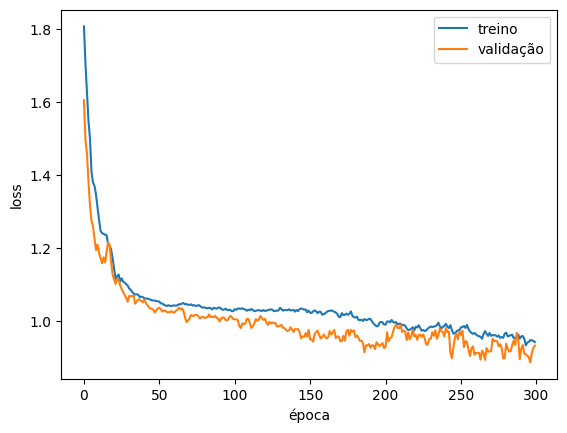

In [10]:
plt.plot(train_losses, label="treino")
plt.plot(val_losses,   label="validação")
plt.xlabel("época")
plt.ylabel("loss")
plt.legend()
plt.show()

## Relatório de classificação

O relatório exibe precisão, revocação e F1-score por classe, além das médias macro e ponderada.

In [11]:
print(classification_report(y_ts.numpy(), preds.numpy()))

              precision    recall  f1-score   support

           0       0.39      0.79      0.52        47
           1       0.65      0.33      0.44        52
           2       0.47      0.27      0.34        55

    accuracy                           0.45       154
   macro avg       0.50      0.46      0.43       154
weighted avg       0.51      0.45      0.43       154



## Matriz de confusão

A matriz de confusão permite identificar quais pares de classes são mais frequentemente confundidos entre si.

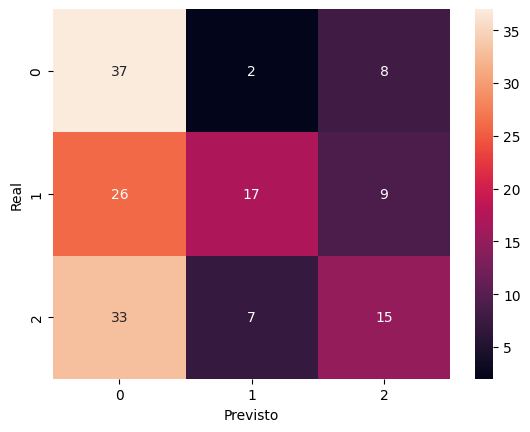

In [12]:
cm = confusion_matrix(y_ts.numpy(), preds.numpy())
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Discussão e resultados

### Contexto do problema

Os dados utilizados são medidas experimentais de dispositivos de papel submetidos a variações de massa e corrente elétrica. Por serem experimentais, apresentam ruído inerente e quantidade limitada de amostras — 12 dispositivos, totalizando aproximadamente 1560 pontos antes do janelamento. As medições não foram realizadas em condições ideais, o que amplifica o ruído e contribui para a sobreposição entre classes no espaço de features. Portanto, a acurácia absoluta não é o único critério relevante de avaliação, mas também são critérios importantes a consistência entre treino e validação e o comportamento por classe.

### Desempenho

A acurácia global no conjunto de teste foi de 45%, contra 33% esperado para um classificador aleatório de três classes — confirmando que a rede aprendeu estrutura nos dados, ainda que de forma modesta. As curvas de perda convergem juntas ao longo das 300 épocas, sem divergência sistemática entre treino e validação, o que indica ausência de overfitting significativo.

A análise por classe revela comportamentos distintos. A classe 0 (papel filme) apresenta alta revocação (79%), mas baixa precisão (39%): a rede a identifica com frequência, mas também classifica erroneamente amostras de outras classes como papel filme. A classe 1 (papel texturizado) tem o comportamento oposto — maior precisão (65%), mas baixa revocação (33%). A classe 2 (lixa) apresenta o pior desempenho em ambas as métricas (F1 = 0,34).

A matriz de confusão evidencia o padrão central de erro: as classes 1 e 2 são sistematicamente atraídas para a classe 0. Das 52 amostras reais de papel texturizado, 26 foram classificadas como papel filme — mais do que as 17 classificadas corretamente. Das 55 amostras de lixa, 33 foram classificadas como papel filme. Esse comportamento sugere que o papel filme ocupa uma região central ou difusa no espaço `variacao_relativa` × `massa_g`, tornando-se o destino preferencial para amostras ambíguas.

### Escolha da arquitetura

A SNN foi escolhida por sua compatibilidade natural com dados temporais (ESHRAGHIAN _et al_, 2023): os neurônios LIF integram a informação ao longo dos `T = 20` passos de cada janela, acumulando evidência antes de emitir um pulso. Isso é uma vantagem sobre a MLP clássica, que trata cada janela como um vetor estático sem considerar a ordem dos instantes. O parâmetro `β = 0,9` implica uma constante de tempo relativamente longa — os neurônios retêm memória de aproximadamente 10 instantes anteriores com peso relevante — o que é adequado para janelas de 20 pontos.

### Limitações

A principal limitação é o espaço de features reduzido (SVOBODA _et al_, 2025): com apenas `variacao_relativa` e `massa_g`, a separação entre classes depende inteiramente de dois atributos que, dado o ruído experimental, não oferecem fronteiras de decisão nítidas. A perda final (~0,95) ainda próxima de `ln(3) ≈ 1,099` é indicativa dessa sobreposição.

### Perspectivas

Para trabalhos futuros, pretende-se aprimorar a montagem experimental a fim de reduzir o ruído nas medições e aumentar a quantidade de amostras por classe, ampliando a base de dados disponível para o treinamento. Em paralelo, pretende-se explorar a inclusão de features derivadas da série temporal — como média, desvio padrão e taxa de variação dentro da janela — e investigar o efeito de diferentes valores de β e tamanhos de janela sobre o desempenho da SNN.


Para mais informações, acesse o GitHub: https://github.com/GiselaCK/dispositivo-de-papel

## Referências:

- ESHRAGHIAN, Jason K et al. Training spiking neural networks using lessons from deep learning. arXiv preprint, arXiv:2109.12894v6, 2023. Disponível em: https://arxiv.org/abs/2109.12894. Acesso em: 07 jun. 2026.
- SVOBODA, Kama; ADEGBIJA, Tosiron. Spiking Neural Network Architecture Search: A Survey. arXiv preprint, arXiv:2510.14235, 2025. Disponível em: https://arxiv.org/abs/2510.14235. Acesso em: 07 jun. 2026.
